# Evaluation of model parameter based clustering

In [16]:
import xarray as xr
import arviz as az
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#from fit_trajectories import gof_trajectories
from scipy.stats import spearmanr, pearsonr

ds = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc")
mask = (ds.tpm.max(dim="time", skipna=True) > 0.1).all(dim="source") 
relevant_genes = ds.sel(ensembl_gene_id=mask).ensembl_gene_id.values

col_m = sns.color_palette("Dark2")  
mod_color_dict = {"Basic": col_m[7],"M-decay": col_m[1], "Z-decay": col_m[4],} 
model_order = ["Basic", "M-decay", "Z-decay"]
sc = "all"
norm="zscore"

gams_cluster_order = ["SD", "SU", "DSU", "N/A"]
gams_cluster_names = {0 : "SD", 1:"SU", 2:"DSU", 3: "SU", 4: "DSU", np.nan: "N/A"}

p_cluster_order = ["TU", "SD", "SU", "DSU", "N/A"]
p_cluster_names = {1:"SD", 0: "TU",2: "SU", 3: "DSU", 4:"SU", np.nan: "N/A"}

col_c = sns.color_palette("Set1", n_colors=8)  
cluster_color_dict = {"SD": col_c[0], "DSD": col_c[1], "SU": col_c[2], "DSU": col_c[3], 
                      "TD-SU": col_c[4], "TU": col_c[7], }

col_c = sns.color_palette("Set1", n_colors=9)  
cluster_color_dict = {"SD": col_c[0], "DSD": col_c[1], "SU": col_c[2], "DSU": col_c[3], "TU": "gold", 
                      "pre-ZGA SU": "lightgreen", "TD-SU": col_c[4], "TU-SD": col_c[7], "TU-DSD": col_c[6], 
                      "N/A":"lightgray"}

subcluster_color_map = {"TU-DSD":sns.color_palette("copper", 3),
             "TD-SU":sns.color_palette("Oranges_r", 3),
             "SU":sns.color_palette("Greens_d", 3),
             "TU":sns.color_palette("RdPu_r", 7),
             "SD":sns.color_palette("Reds_d", 7),
             "DSD":sns.color_palette("Blues_d", 4),
             "DSU":sns.color_palette("Purples_d",4),
             "TU-DSD":sns.color_palette("YlGn",4),
            }


## join param results datasets

In [2]:
cluster_genes = xr.load_dataset(f"results/{sc}_gene_cluster_annotation_{norm}.nc").ensembl_gene_id.values
# accepted genes
acc_genes = pd.read_csv("../acc_genes.csv").gene_id.values

print("accepted genes fit evaluation", acc_genes.size)

# join datasets
dsm = xr.load_dataset(f"../results/results_summary/Rep_M/params_results.nc")
dsz = xr.load_dataset(f"../results/results_summary/Rep_Z/params_results.nc")

traj_m = xr.load_dataset(f"../results/results_summary/Rep_M/simulation_results.nc").mean(dim="source")
traj_z = xr.load_dataset(f"../results/results_summary/Rep_Z/simulation_results.nc").mean(dim="source")

#common_genes = list(set(traj_z.ensembl_gene_id.values) & set(traj_m.ensembl_gene_id.values)) 
# dsm = dsm.sel(ensembl_gene_id=common_genes)
# dsz =dsz.sel(ensembl_gene_id=common_genes)
# traj_m = traj_m.sel(ensembl_gene_id=common_genes)
# traj_z = traj_z.sel(ensembl_gene_id=common_genes)

dsm = dsm.expand_dims(model=["M"])
dsz = dsz.expand_dims(model=["Z"])

traj_m = traj_m.expand_dims(model=["M"])
traj_z = traj_z.expand_dims(model=["Z"])

ds = xr.concat([dsm, dsz], dim="model")
traj = xr.concat([traj_m, traj_z], dim="model")

# choose best model by BIC --> also check for R hat??
gof_M = pd.read_csv("../results/results_summary/Rep_M/goodness_of_fit_summary.csv")[["gene_id", "BIC"]].rename(columns={"BIC":"BIC_M"}).set_index("gene_id")
gof_Z = pd.read_csv("../results/results_summary/Rep_Z/goodness_of_fit_summary.csv")[["gene_id", "BIC"]].rename(columns={"BIC":"BIC_Z"}).set_index("gene_id")
gof = gof_M.join(gof_Z, how="left").reset_index()
#gof["decay_mode"] = np.where(gof["BIC_M"] == gof["BIC_Z"], "0", "")
gof["decay_mode"] = np.where(gof["BIC_M"] <= gof["BIC_Z"], "M", "Z") # 1 = M preferred, -1 = Z preferred
gof["dBIC"] = abs(gof["BIC_M"] - gof["BIC_Z"])
gof["significant"] = np.where(gof["dBIC"] > 6, True, False) # strong model evidence: dBIC > 6
gof = gof.set_index("gene_id")
gof.index.name = "ensembl_gene_id"

# decay_mode DataArray
selection_da = xr.DataArray(gof["decay_mode"],dims=["ensembl_gene_id"],coords={"ensembl_gene_id": gof.index},)

print("total number of genes", len(selection_da))
ds_selected = ds.sel(model=selection_da, ensembl_gene_id=selection_da.ensembl_gene_id.values)
traj_selected = traj.sel(model=selection_da, ensembl_gene_id=selection_da.ensembl_gene_id.values)

# assing new param for model selection
# map M -> 1, Z -> 0
selection_num = gof["decay_mode"].map({"M": 1, "Z": 0})
selection_num_da = xr.DataArray(selection_num, dims=["ensembl_gene_id"], coords={"ensembl_gene_id": gof.index},).reindex(ensembl_gene_id=ds_selected.ensembl_gene_id)
ds_selected["decay_mode"] = selection_num_da

param_cluster_label = xr.load_dataset("results/joint_param_superclusters_labels.nc").cluster_label

traj_selected["supercluster"] = param_cluster_label
print("unclustered genes", traj_selected.supercluster.isnull().sum().item())  # any unmatched genes?
traj_selected = traj_selected.rename_vars({"y":"tpm"})
peak_idx = np.argmax(traj_selected["tpm"].values, axis=1)  # one index per gene
peak_time_values = traj_selected["time"].values[peak_idx]   # or traj_selected.time.values[np.arange(n), peak_idx] if time varies per-row

ds_selected["peak_time"] = ("ensembl_gene_id", peak_time_values)
ds_selected["maternal_half_life"] = np.log(2) / ds_selected["delta_m"]
ds_selected["repression_ratio"] = ds_selected["beta"] / ds_selected["alpha"]
ds_selected["y0"] = traj_selected.sel(time=0).M


gof = gof.reset_index()

missing_in_ds = set(cluster_genes) - set(ds_selected["ensembl_gene_id"].values)
missing_in_traj = set(cluster_genes) - set(traj_selected["ensembl_gene_id"].values)

print(f"{len(missing_in_ds)} genes missing from ds_selected")
print(f"{len(missing_in_traj)} genes missing from traj_selected")
print(list(missing_in_ds)[:10])


ds_selected.to_netcdf("all_params_results.nc")
traj_selected.to_netcdf("all_simulation_results.nc")
gof.to_csv("all_prefered_decay_mode.csv", index=False)

valid_genes = (set(acc_genes)
               & set(ds_selected["ensembl_gene_id"].values)
               & set(traj_selected["ensembl_gene_id"].values))

print("valid genes", len(valid_genes))
#cluster_genes = [g for g in cluster_genes if g in valid_genes]

gof = gof[gof["ensembl_gene_id"].isin(valid_genes)]
ds_selected = ds_selected.sel(ensembl_gene_id=list(valid_genes))
traj_selected = traj_selected.sel(ensembl_gene_id=list(valid_genes))

# save dataset
ds_selected.to_netcdf("joint_params_results.nc")
traj_selected.to_netcdf("joint_simulation_results.nc")
gof.to_csv("prefered_decay_mode.csv", index=False)

traj_selected ## TODO: all labels
ds_selected

accepted genes fit evaluation 26957
total number of genes 31658
unclustered genes 4701
0 genes missing from ds_selected
0 genes missing from traj_selected
[]


C:\Users\mgrho\AppData\Local\Temp\ipykernel_4180\2633535725.py:78: SerializationWarning: saving variable supercluster with floating point data as an integer dtype without any _FillValue to use for NaNs
  traj_selected.to_netcdf("all_simulation_results.nc")
c:\Users\mgrho\anaconda3\envs\polya\Lib\site-packages\xarray\coding\variables.py:558: RuntimeWarning: invalid value encountered in cast
  data = data.astype(dtype=dtype)


valid genes 26957


C:\Users\mgrho\AppData\Local\Temp\ipykernel_4180\2633535725.py:94: SerializationWarning: saving variable supercluster with floating point data as an integer dtype without any _FillValue to use for NaNs
  traj_selected.to_netcdf("joint_simulation_results.nc")


<xarray.Dataset>
Dimensions:             (ensembl_gene_id: 26957)
Coordinates:
    model               (ensembl_gene_id) object 'Z' 'M' 'Z' 'Z' ... 'Z' 'Z' 'Z'
  * ensembl_gene_id     (ensembl_gene_id) <U18 'ENSDARG00000022569' ... 'ENSD...
    time                float64 0.0
Data variables:
    alpha               (ensembl_gene_id) float64 2.33 12.13 ... 1.825 16.21
    beta                (ensembl_gene_id) float64 0.6643 0.174 ... 1.311 0.8216
    delta_m             (ensembl_gene_id) float64 1.563 0.5496 ... 1.973 1.172
    sigma_y             (ensembl_gene_id) float64 0.2886 0.6219 ... 0.4364
    t_rep               (ensembl_gene_id) float64 55.04 2.873 ... 24.62 1.868
    t_zga               (ensembl_gene_id) float64 3.559 1.149 ... 0.5428 0.7131
    t_reg               (ensembl_gene_id) float64 58.6 4.021 ... 25.17 2.581
    decay_mode          (ensembl_gene_id) int64 0 1 0 0 1 0 0 ... 1 1 1 1 0 0 0
    peak_time           (ensembl_gene_id) float64 51.6 4.33 120.0 ... 23.22 3.0
    maternal_half_life  (ensembl_gene_id) float64 0.4434 1.261 ... 0.3513 0.5916
    repression_ratio    (ensembl_gene_id) float64 0.2851 0.01434 ... 0.05067
    y0                  (ensembl_gene_id) float64 0.07205 0.1598 ... 1.264 51.43

In [3]:
xr.load_dataset("joint_params_results.nc")

<xarray.Dataset>
Dimensions:             (ensembl_gene_id: 26957)
Coordinates:
  * ensembl_gene_id     (ensembl_gene_id) object 'ENSDARG00000022569' ... 'EN...
    model               (ensembl_gene_id) object 'Z' 'M' 'Z' 'Z' ... 'Z' 'Z' 'Z'
    time                float64 0.0
Data variables:
    alpha               (ensembl_gene_id) float64 2.33 12.13 ... 1.825 16.21
    beta                (ensembl_gene_id) float64 0.6643 0.174 ... 1.311 0.8216
    delta_m             (ensembl_gene_id) float64 1.563 0.5496 ... 1.973 1.172
    sigma_y             (ensembl_gene_id) float64 0.2886 0.6219 ... 0.4364
    t_rep               (ensembl_gene_id) float64 55.04 2.873 ... 24.62 1.868
    t_zga               (ensembl_gene_id) float64 3.559 1.149 ... 0.5428 0.7131
    t_reg               (ensembl_gene_id) float64 58.6 4.021 ... 25.17 2.581
    decay_mode          (ensembl_gene_id) int32 0 1 0 0 1 0 0 ... 1 1 1 1 0 0 0
    peak_time           (ensembl_gene_id) float64 51.6 4.33 120.0 ... 23.22 3.0
    maternal_half_life  (ensembl_gene_id) float64 0.4434 1.261 ... 0.3513 0.5916
    repression_ratio    (ensembl_gene_id) float64 0.2851 0.01434 ... 0.05067
    y0                  (ensembl_gene_id) float64 0.07205 0.1598 ... 1.264 51.43

In [4]:
import numpy as np
import xarray as xr

# Load the results
membership = xr.load_dataarray("results/all_superclusters_membership.nc")
centers = xr.load_dataarray("results/all_superclusters_centers.nc")

# For each cluster, find genes with highest membership
for cluster_idx in range(membership.cluster.size):
    # Get genes sorted by membership to this cluster    
    top_genes = (
        membership
        .sel(cluster=cluster_idx)
        .sortby(-membership.sel(cluster=cluster_idx))
        .isel(ensembl_gene_id=slice(0, 1))  # Top 20 genes
    )
    
    print(f"Cluster {cluster_idx} top genes:")
    print(top_genes.ensembl_gene_id.values)


Cluster 0 top genes:
['ENSDARG00000098622']
Cluster 1 top genes:
['ENSDARG00000093019']
Cluster 2 top genes:
['ENSDARG00000116991']


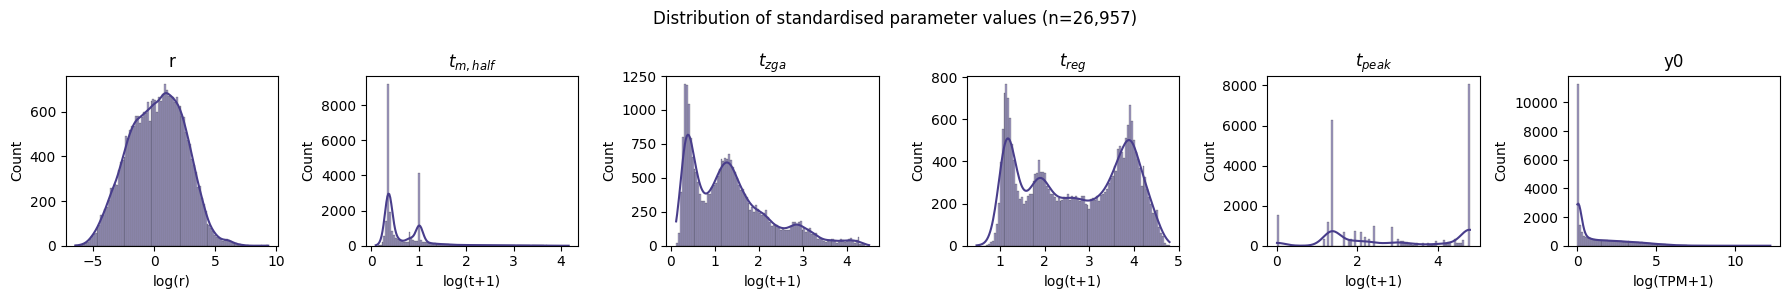

In [5]:
# plot params distribution
params = [ "alpha", "beta", "delta_m", "t_zga", "t_reg"]
params = ["repression_ratio", "maternal_half_life", "t_zga", "t_reg", "peak_time", "y0" ]
#params = [ "alpha", "beta", "delta_m",  "t_zga", "t_reg", "peak_time"]
#params = ["repression_ratio", "maternal_half_life", "t_zga", "t_reg", "peak_time", "decay_mode", ]

title = ["r", "$t_{m, half}$", "$t_{zga}$",  "$t_{reg}$", "$t_{peak}$", "y0"]
labels = ["log(r)", "log(t+1)", "log(t+1)", "log(t+1)", "log(t+1)", "log(TPM+1)"]

model ="joint"
fig, ax = plt.subplots(1, len(params), figsize=(3*len(params), 3)) 

ds = xr.load_dataset(f"joint_params_results.nc")
traj = xr.load_dataset(f"joint_simulation_results.nc")

ds["repression_ratio"] = ds.alpha.clip(min=1e-5)
ds["alpha"] = ds.alpha.clip(min=1e-5)
ds["beta"] = ds.beta.clip(min=1e-5)
ds["delta_m"] = ds.delta_m.clip(min=1e-5)
ds["t_zga"] = ds.t_zga.clip(max=120)
ds["t_reg"] = ds.t_reg.clip(max=120)

ds["repression_ratio"] = np.log(ds["repression_ratio"])
ds["maternal_half_life"] = np.log1p(ds["maternal_half_life"])
ds["t_zga"] = np.log1p(ds["t_zga"])
ds["t_reg"] = np.log1p(ds["t_reg"])
ds["peak_time"] = np.log1p(ds["peak_time"])
ds["y0"] = np.log1p(ds["y0"])
x = ds

u = x.mean()
s= x.std()
z_x = (x-u)/s

for i, par in enumerate(params):
    sns.histplot(x[par], ax=ax[i], kde=True, bins=100, color="darkslateblue",)
    #sns.kdeplot(z_x[par], ax=ax[n][i], color=mod_color_dict[model], )
    ax[i].set(title= title[i], xlabel=labels[i])

# ax[0].text(0.01,1.1, s=f"{model}", transform=ax[n][0].transAxes, bbox=dict(facecolor=mod_color_dict[model], alpha=0.5))
# ax[3].axvline(x=np.log(3), c="k", ls="--")
# ax[4].axvline(x=np.log(3), c="k", ls="--")
plt.suptitle(f"Distribution of standardised parameter values (n={len(ds.ensembl_gene_id.values):,})")
plt.tight_layout()
plt.savefig(f"figs/joint_param_dist.png", dpi=300)
plt.show()

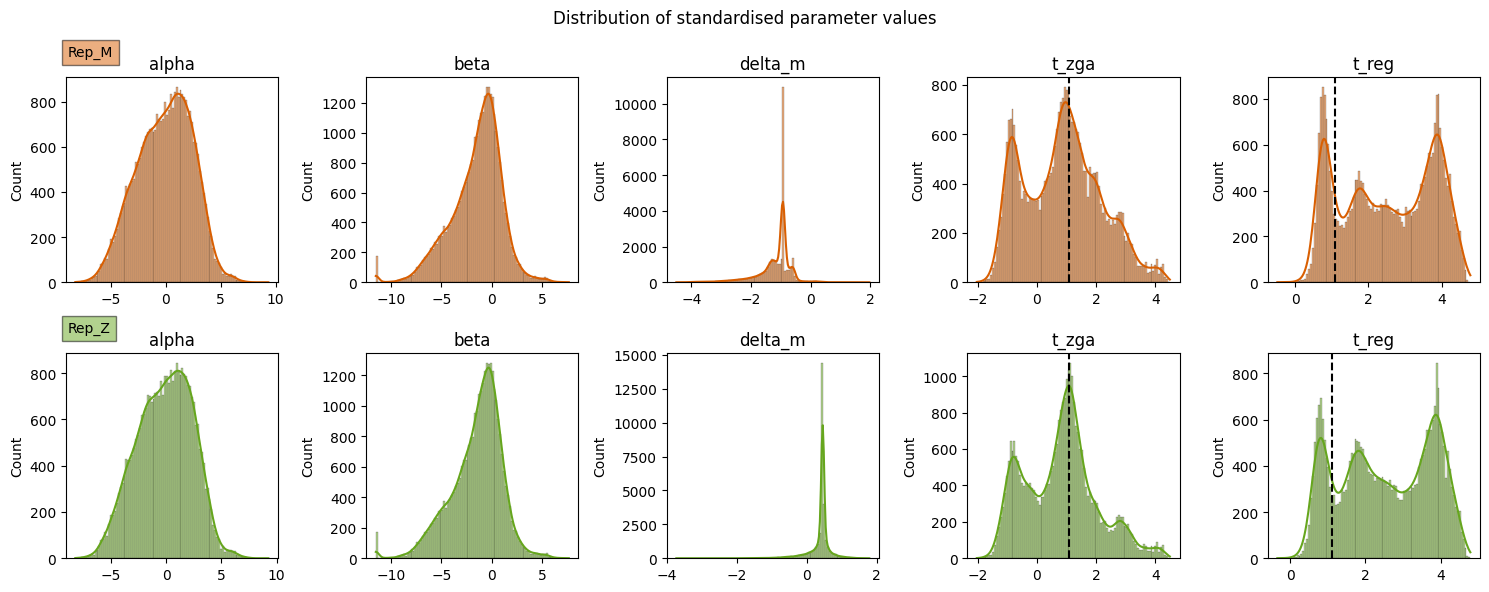

In [6]:
# plot params distribution
params = [ "alpha", "beta", "delta_m", "t_zga", "t_reg"]
#params = [ "alpha", "beta", "delta_m",  "t_zga", "t_reg", "peak_time"]

models = ["Rep_M", "Rep_Z"]
fig, ax = plt.subplots(len(models), len(params), figsize=(3*len(params), 3*(len(models)))) 

for n, model in enumerate(models):
    ds = xr.load_dataset(f"../results/results_summary/{model}/params_results.nc")
    traj = xr.load_dataset(f"../results/results_summary/{model}/simulation_results.nc").mean(dim="source")

    ds["alpha"] = ds.alpha.clip(min=1e-5)
    ds["beta"] = ds.beta.clip(min=1e-5)
    ds["delta_m"] = ds.delta_m.clip(min=1e-5)
    ds["t_zga"] = ds.t_zga.clip(max=120)
    ds["t_reg"] = ds.t_reg.clip(max=120)

    x = np.log(ds)

    x["peak_time"] = traj.time[np.argmax(traj.y.values, axis=1)]

    u = x.mean()
    s= x.std()
    z_x = (x-u)/s
    
    mod = ["M-decay", "Z-decay"][n]

    for i, par in enumerate(params):
        
        sns.histplot(x[par], ax=ax[n][i], color=mod_color_dict[mod], kde=True, bins=100)
        #sns.kdeplot(z_x[par], ax=ax[n][i], color=mod_color_dict[model], )

        ax[n][i].set(title= par)
    ax[n][0].text(0.01,1.1, s=f"{model}", transform=ax[n][0].transAxes, bbox=dict(facecolor=mod_color_dict[mod], alpha=0.5))
    ax[n][3].axvline(x=np.log(3), c="k", ls="--")
    ax[n][4].axvline(x=np.log(3), c="k", ls="--")
plt.suptitle(f"Distribution of standardised parameter values")
plt.tight_layout()
plt.savefig(f"figs/param_dist.png", dpi=300)
plt.show()

### plot cluster centers

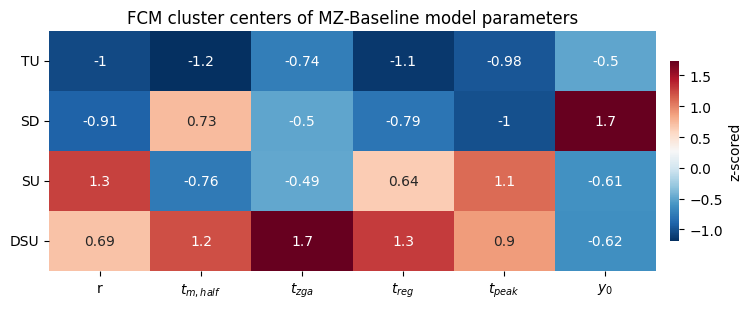

In [7]:
def plot_cluster_centers(da, dataset_name):
    """
    Heatmap of standardized cluster centers: one row per cluster, one
    column per parameter. Replaces the trajectory line plot from the
    time-series version, since there's no time axis here.
    """
    xlabel = ["r", "$t_{m, half}$", "$t_{zga}$",  "$t_{reg}$", "$t_{peak}$", "$y_0$"] #"decay mode"]

    # Min-max: (x - min) / (max - min), computed along "cluster" for each feature
    dmin = da.min(dim="cluster")
    dmax = da.max(dim="cluster")
    da_minmax = (da - dmin) / (dmax - dmin)

    # zscore
    dsd = da.std(dim="cluster")
    dmean = da.mean(dim="cluster")
    da_zscore = (da -dmean) / dsd

    da["cluster_centers"] = da_zscore

    k = da.sizes["cluster"]
    features = da.feature.values

    plt.rcParams['font.family'] = 'sans-serif'
    fig, ax = plt.subplots(figsize=(1 * len(features) + 2, 0.3 * k + 2))
    

    sns.heatmap(data=da.cluster_centers, cmap="RdBu_r", annot=True,
                cbar_kws={'label': 'z-scored', 'shrink': 0.75, 'pad': 0.02 })

    ax.set_xticklabels(xlabel, rotation=0)
    ax.set_yticklabels([f"{p_cluster_names[c]}" for c in range(k)], rotation=0)

    ax.set_title(f"FCM cluster centers of MZ-Baseline model parameters")

    fig.tight_layout()
    fig.savefig(f"figs/FCM_param_cluster_center_{dataset_name}.png", dpi=300)
    plt.show(fig)

#centers_std_da = xr.load_dataset(f"results/joint_param_superclusters_centers.nc")
centers_da = xr.load_dataset(f"results/joint_param_superclusters_centers_orig.nc")
da = centers_da["cluster_centers_original_units"]
plot_cluster_centers(da, "joint")

### model cluster validation

Number of genes in dataset: 26957


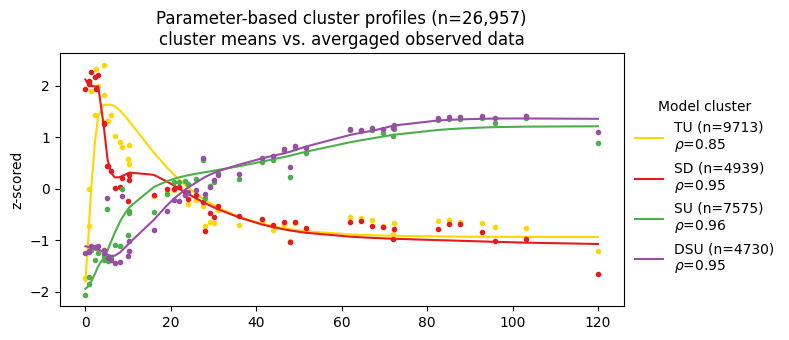

,supercluster,RMSE,r2,spearmanr,pearsonr
0,0,0.501680,0.748317,0.847107,0.874159
1,1,0.212418,0.954879,0.946507,0.977439
2,2,0.278570,0.922399,0.963601,0.961199
3,3,0.251300,0.936849,0.946603,0.968424


In [8]:
# parameter

def minmax(curve):
    mn = curve.min("time")
    mx = curve.max("time")
    return (curve - mn) / (mx - mn)

def zscore(curve):
    sd = curve.std("time")
    return (curve - curve.mean("time")) / sd

def rmse(a, b):
    mask = ~np.isnan(a) & ~np.isnan(b)
    return np.sqrt(np.mean((a[mask] - b[mask])**2)).item()

def r2(y_true, y_pred):
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    ss_res = np.sum((y_true[mask] - y_pred[mask])**2)
    ss_tot = np.sum((y_true[mask] - np.mean(y_true[mask]))**2)
    return (1 - ss_res/ss_tot).item()

from scipy.stats import spearmanr, pearsonr
ds = xr.load_dataset(f"joint_simulation_results.nc")
labels =  xr.load_dataset("results/joint_param_superclusters_labels.nc")
obs = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc").mean(dim="source").sel(ensembl_gene_id = ds.ensembl_gene_id.values)

ds["tpm"] = np.log(ds.tpm + 1)
obs["tpm"] = np.log(obs.tpm + 1)

print(f"Number of genes in dataset: {len(labels.cluster_label.ensembl_gene_id)}")

gof = []

plt.figure(figsize=(8,3.5))
plt.rcParams['font.family'] = 'sans-serif'
for c in np.unique(labels.cluster_label.values):

    cluster_name = p_cluster_names[c]

    gene_ids = labels['ensembl_gene_id'][labels['cluster_label'] == c].values

    obs_c = obs.sel(ensembl_gene_id=gene_ids)
    obs_c_mean = zscore(obs_c.tpm.mean(dim=("ensembl_gene_id")))
    obs_c_std = zscore(obs_c.tpm.std(dim=("ensembl_gene_id",)))

    ds_c = ds.sel(ensembl_gene_id=gene_ids)
    ds_c_mean = zscore(ds_c.tpm.mean(dim=("ensembl_gene_id")))
    ds_c_std = zscore(ds_c.tpm.std(dim=("ensembl_gene_id",)))

    plt.plot(ds_c_mean.time, ds_c_mean, "-", c=cluster_color_dict[cluster_name],
             label=f"{cluster_name} (n={ds_c.ensembl_gene_id.size})\n"+r"$\rho$"+f"={spearmanr(obs_c_mean, ds_c_mean)[0]:.2f}", )
    plt.plot(obs_c_mean.time, obs_c_mean, ".", c=cluster_color_dict[cluster_name], )

    #plt.fill_between(ds_c_mean.time.values, ds_c_mean - ds_c_std,ds_c_mean + ds_c_std, alpha=0.05, color=colors[c])

    gof.append({"supercluster":c, "RMSE":rmse(obs_c_mean, ds_c_mean),  "r2":r2(obs_c_mean, ds_c_mean),  
                "spearmanr": spearmanr(obs_c_mean, ds_c_mean)[0], "pearsonr":pearsonr(obs_c_mean, ds_c_mean)[0]})
   
pd.DataFrame(gof).to_excel("cluster_validation.xlsx")

#plt.xlim(0, 20)
plt.title(f"Parameter-based cluster profiles (n={len(labels.cluster_label.ensembl_gene_id):,})\ncluster means vs. avergaged observed data")
plt.ylabel("z-scored")
plt.legend(loc=(1.01, 0.1), frameon=False, title="Model cluster")
plt.tight_layout()
plt.savefig("figs/param_cluster_validation.png", dpi=300)
plt.show()
pd.DataFrame(gof)

In [9]:
## distribution of model parameters per cluster 

title = {"repression_ratio":"r", 
         "maternal_half_life":"$t_{m, half}$", 
         "t_zga":"$t_{zga}$",  
         "t_reg":"$t_{reg}$", 
         "peak_time":"$t_{peak}$", 
         "y0": "y_0", }


def plot_super_subcluster_grid(parameter_da, param, super_labels, sub_labels, show_tzga=True):

    data = parameter_da[param]

    super_ids = np.unique(super_labels)
    groups = {spc: np.unique(sub_labels[(super_labels == spc) & (sub_labels >= 0)]) for spc in super_ids}

    ncols = 4         # 1 supercluster-mean column + up to 4 subcluster columns
    max_sub_per_row = ncols - 1

    # number of rows needed per supercluster (wrap subclusters in groups of 4)
    rows_per_super = {spc: max(1, int(np.ceil(len(groups[spc]) / max_sub_per_row))) for spc in super_ids}
    nrows = sum(rows_per_super.values())

    figsize = (2.5 * ncols, 1.5 * nrows)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, sharex=True, sharey=False)
    axes = np.atleast_2d(axes)

    row = 0
    for spc in super_ids:
        sub_ids = groups[spc]
        sc_name = p_cluster_names[spc]
        n_rows_sc = rows_per_super[spc]

        # plot supercluster mean only on the first row for this supercluster
        idx = np.where(super_labels == spc)[0]
        subset = data[idx]

        sns.histplot(subset, log_scale=True, kde=True, alpha=0.1, ax=axes[row, 0], color=cluster_color_dict[sc_name], bins=40)
        axes[row, 0].set_title(f"Supercluster {sc_name} ({len(subset)})", fontsize=9)
        axes[row, 0].axvline(x=3, ls="--", c="k", lw=1)

        # hide the supercluster column on any continuation rows
        for r in range(row + 1, row + n_rows_sc):
            axes[r, 0].set_visible(False)

        # place subclusters, wrapping onto new rows every max_sub_per_row
        for j, sb in enumerate(sub_ids):
            r_offset, c_offset = divmod(j, max_sub_per_row)
            ax = axes[row + r_offset, c_offset + 1]

            idx = np.where((super_labels == spc) & (sub_labels == sb))[0]
            if len(idx) == 0:
                ax.set_visible(False)
                continue

            subset = data[idx]

            sns.histplot(subset, log_scale=True, kde=True, alpha=0.1, ax=ax, color=cluster_color_dict[sc_name], bins=40)

            if show_tzga:
                ax.axvline(x=3, ls="--", c="k", lw=1)
            if param == "repression_ratio":
                ax.axvline(x=1, ls="--", c="k", lw=1)

            ax.set_title(f"{sc_name} - {sb} ({len(subset)})", fontsize=9)
            ax.set(ylabel="")

        # hide any leftover unused subcluster slots in the last row for this supercluster
        n_used_last_row = len(sub_ids) - (n_rows_sc - 1) * max_sub_per_row
        for c in range(n_used_last_row, max_sub_per_row):
            axes[row + n_rows_sc - 1, c + 1].set_visible(False)

        row += n_rows_sc

    fig.suptitle(rf"Distribution of {title[param]} across model parameter-based subclusters", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"figs/param_{param}_kde_subcluster_grid.png", dpi=300)
    plt.show()

parameter_da = xr.load_dataset("joint_params_results.nc")
labels = xr.load_dataset(f"results/joint_gene_params_cluster_annotation.nc")
parameter_da = parameter_da.sel(ensembl_gene_id=labels.ensembl_gene_id)
parameter_da["peak_time"] = parameter_da["peak_time"] +1e-2
parameter_da["y0"] = parameter_da["y0"]+1e-2

super_labels = labels.supercluster.values
sub_labels = labels.subcluster.values


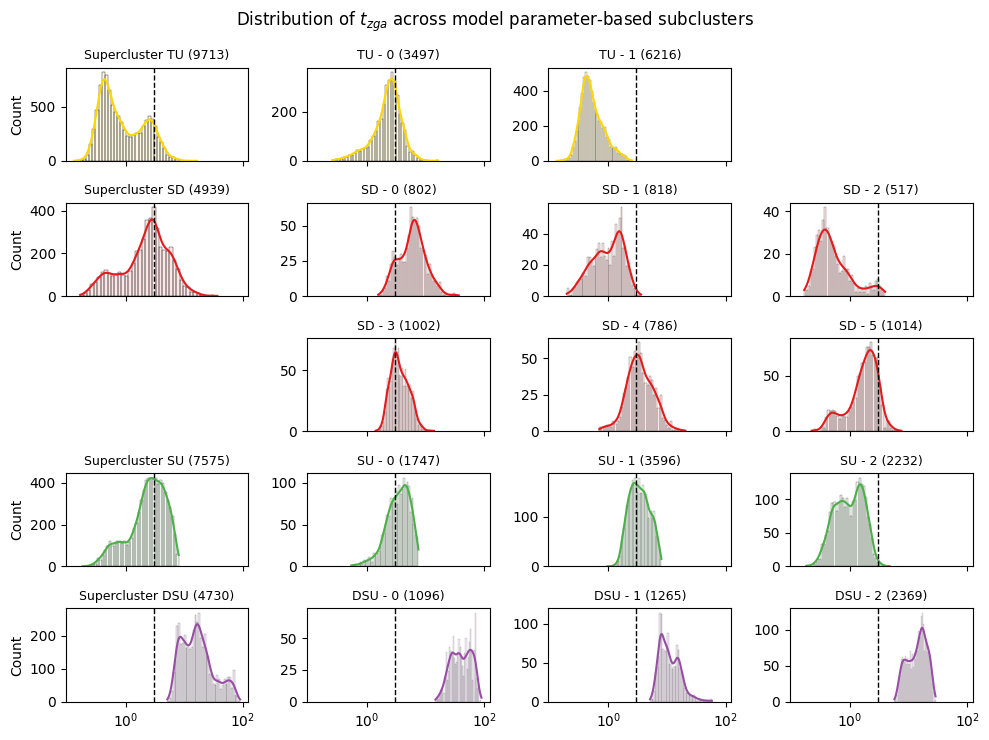

In [10]:
plot_super_subcluster_grid(parameter_da, "t_zga", super_labels, sub_labels, show_tzga=True)

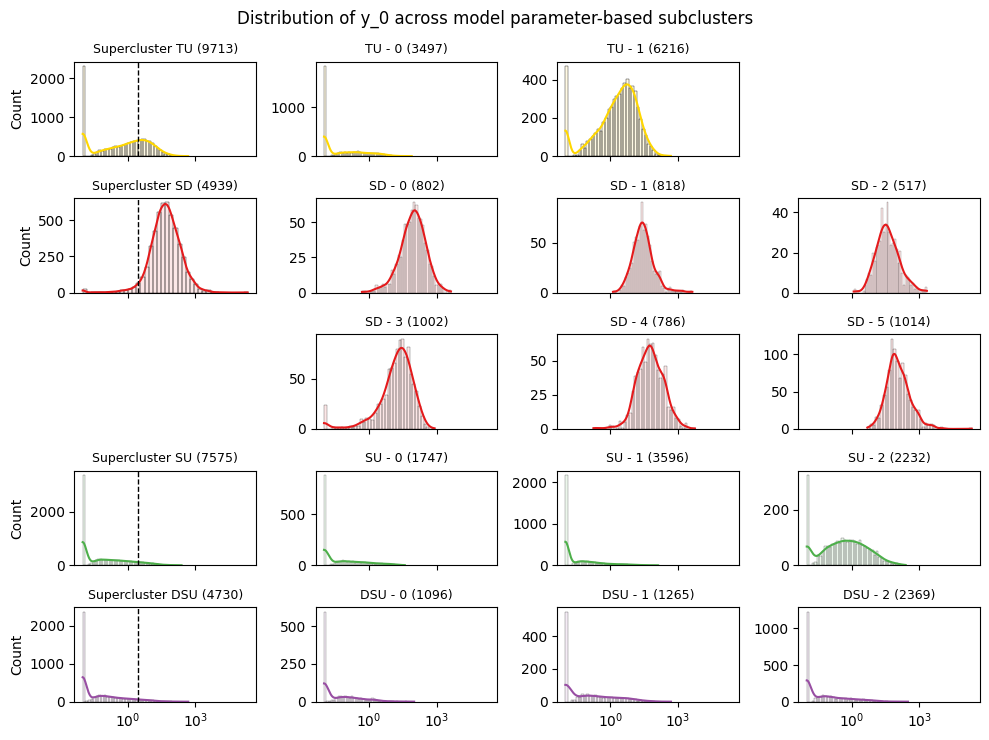

In [11]:
plot_super_subcluster_grid(parameter_da, "y0", super_labels, sub_labels, show_tzga=False)

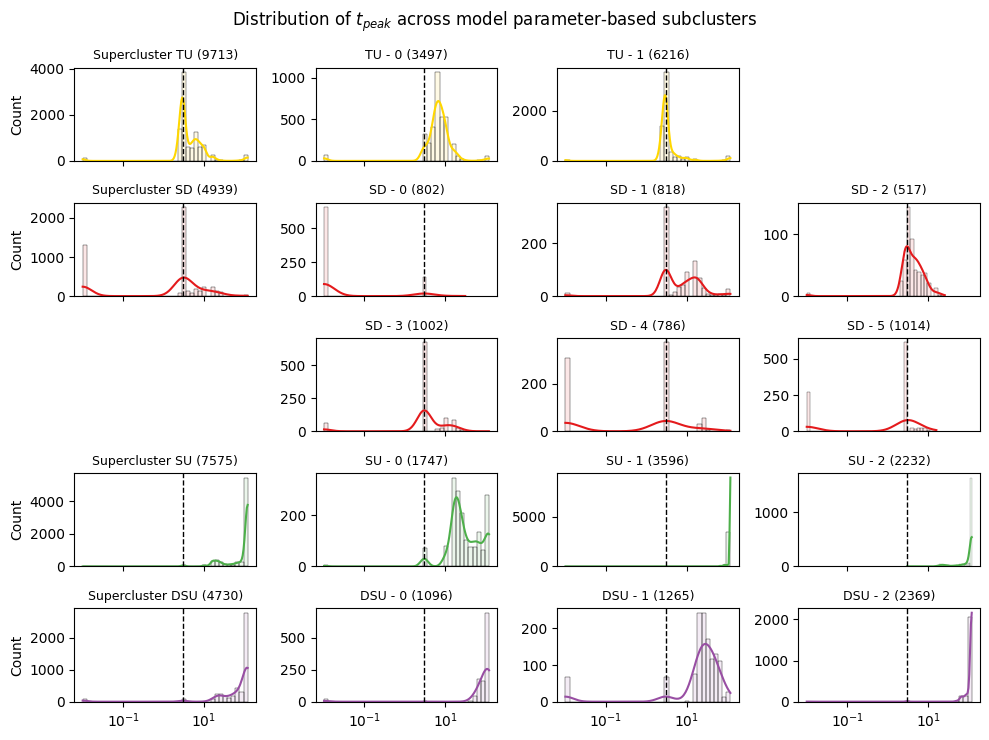

In [12]:
plot_super_subcluster_grid(parameter_da, "peak_time", super_labels, sub_labels)

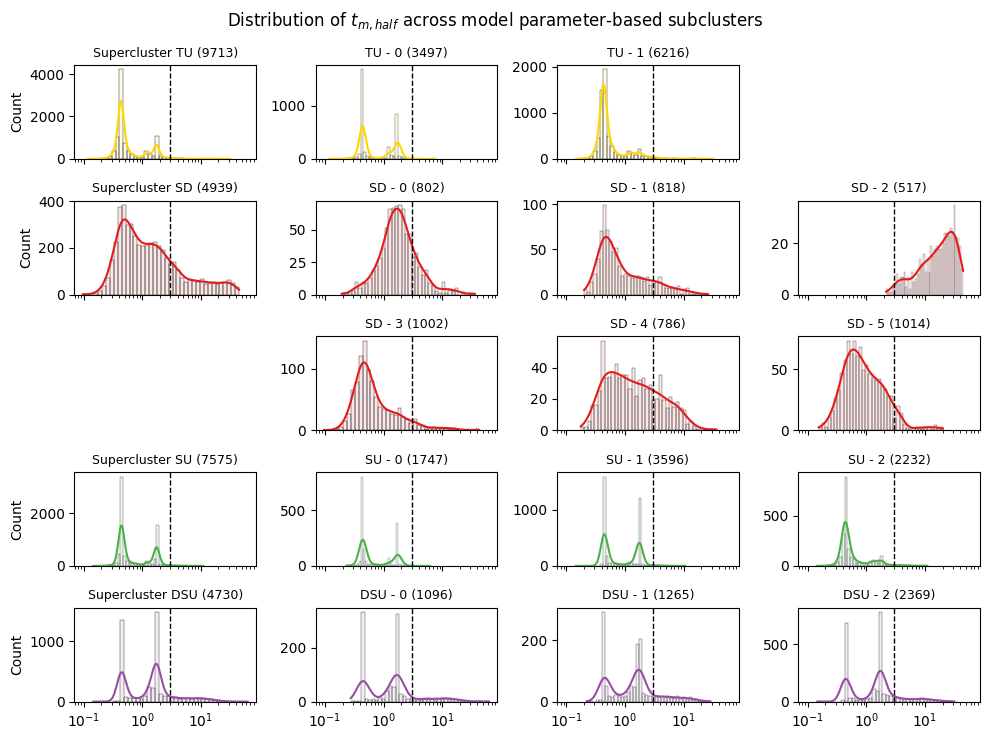

In [13]:
plot_super_subcluster_grid(parameter_da, "maternal_half_life", super_labels, sub_labels)

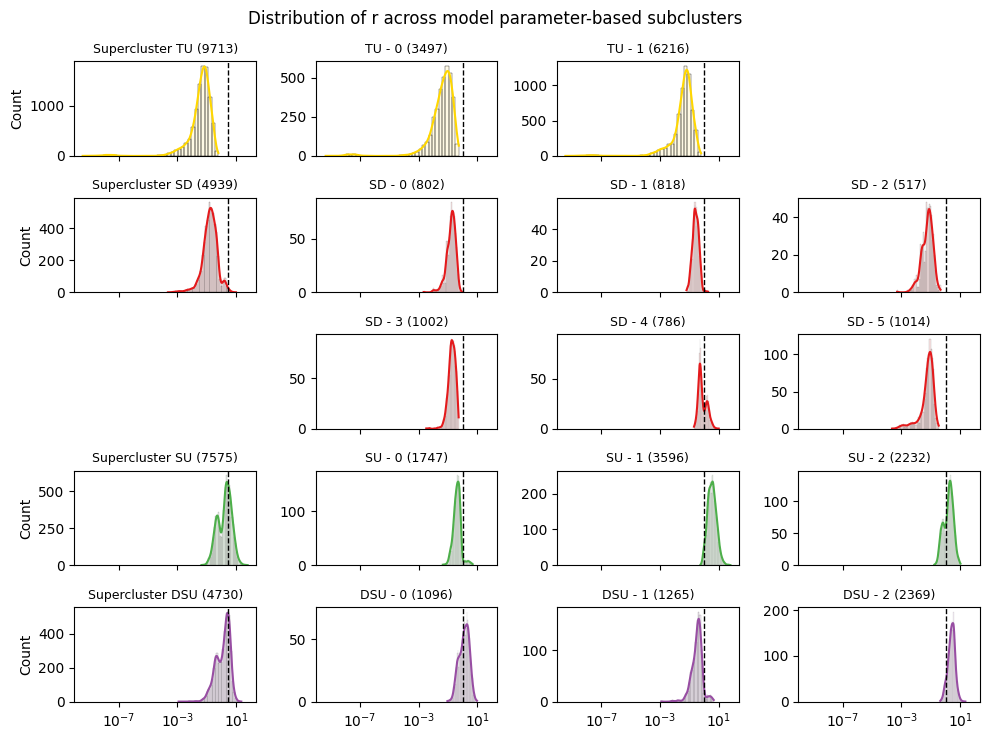

In [14]:
plot_super_subcluster_grid(parameter_da, "repression_ratio", super_labels, sub_labels, show_tzga=False)

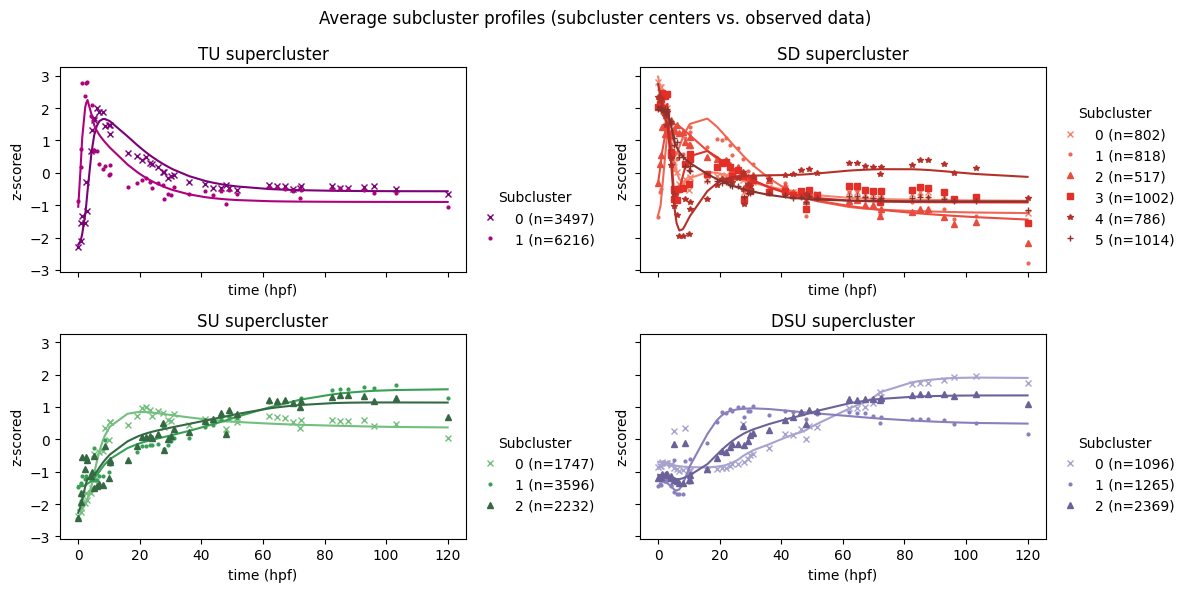

,supercluster,subcluster,RMSE,r2,spearmanr,pearsonr
0,0,0,0.296775,0.911925,0.929220,0.955962
1,0,1,0.492323,0.757618,0.847107,0.878809
2,1,0,0.167132,0.972067,0.954670,0.986033
3,1,1,0.580420,0.663113,0.860072,0.831556
4,1,2,0.221950,0.950738,0.976375,0.975369
5,1,3,0.311161,0.903179,0.830780,0.951589
6,1,4,0.283890,0.919406,0.936038,0.959703
7,1,5,0.118549,0.985946,0.963794,0.992973
8,2,0,0.205412,0.957806,0.863049,0.978903
9,2,1,0.251310,0.936843,0.960432,0.968422


In [17]:
## Subcluster Centers
labels = xr.load_dataset(f"results/joint_gene_params_cluster_annotation.nc")
ds = xr.load_dataset(f"joint_simulation_results.nc")
obs = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc").mean(dim="source").sel(ensembl_gene_id = ds.ensembl_gene_id.values)

ds["tpm"] = np.log2(ds.tpm + 1)
#ds["tpm"] = (ds.tpm - ds.tpm.mean(dim=("time"))) / ds.tpm.std(dim=("time")) #z-score

obs["tpm"] = np.log2(obs.tpm + 1)
#obs["tpm"] = (obs.tpm - obs.tpm.mean(dim=("time"))) / obs.tpm.std(dim=("time")) #z-score=("time")) #z-score

#-----
gof = []
marker_map = {0:"x", 1:".", 2:"^", 3:"s", 4:"*", 5:"+", 6:"p", 7:"d", 8:">"}

fig, ax = plt.subplots(2,2, figsize= (12, 6), sharex=True, sharey=True)
plt.rcParams['font.family'] = 'sans-serif'
ax=ax.flatten()

for k in range(np.unique(labels.supercluster).size):

    genes = labels.ensembl_gene_id.where(labels.supercluster == k,drop=True)
    subtraj = ds.where(ds.ensembl_gene_id.isin(genes.values), drop=True)
    sub_cluster = np.unique(genes.subcluster).size
    #fig, ax = plt.subplots(1,sub_cluster, figsize= (5*sub_cluster, 3), squeeze=False)
    #ax=ax.flatten()
    sc_name = p_cluster_names[k]
    
    for c in range(sub_cluster):

        gene_ids = labels['ensembl_gene_id'][(labels['supercluster'] == k) & (labels['subcluster'] == c)].values

        obs_c = obs.sel(ensembl_gene_id=gene_ids)
        obs_c_mean = zscore(obs_c.tpm.mean(dim=("ensembl_gene_id")))
        obs_c_std = zscore(obs_c.tpm.std(dim=("ensembl_gene_id",)))

        ds_c = ds.sel(ensembl_gene_id=gene_ids)
        ds_c_mean = zscore(ds_c.tpm.mean(dim=("ensembl_gene_id")))
        ds_c_std = zscore(ds_c.tpm.std(dim=("ensembl_gene_id",)))

        ax[k].plot(ds_c_mean.time, ds_c_mean, c=subcluster_color_map[sc_name][c],)
        ax[k].plot(obs_c_mean.time, obs_c_mean, ls="", marker=marker_map[c], ms=4, c=subcluster_color_map[sc_name][c], 
                   label=f"{c} (n={ds_c.ensembl_gene_id.size})")
        
        #ax[c].fill_between(ds_c_mean.time.values, ds_c_mean - ds_c_std,ds_c_mean + ds_c_std, alpha=0.05, color=color_map[k][c])

        gof.append({"supercluster":k, "subcluster":c, "RMSE":rmse(obs_c_mean, ds_c_mean),  "r2":r2(obs_c_mean, ds_c_mean),  
                    "spearmanr": spearmanr(obs_c_mean, ds_c_mean)[0], "pearsonr":pearsonr(obs_c_mean, ds_c_mean)[0]})
        
    ax[k].set(title=f"{p_cluster_names[k]} supercluster", ylabel= "z-scored", xlabel="time (hpf)")
    ax[k].legend(title="Subcluster", loc=(1.01, 0.1),frameon=False)

plt.suptitle("Average subcluster profiles (subcluster centers vs. observed data)")
plt.tight_layout()
plt.savefig(f"figs/params_subcluster_validation.png", dpi=300)
plt.show()

pd.DataFrame(gof)

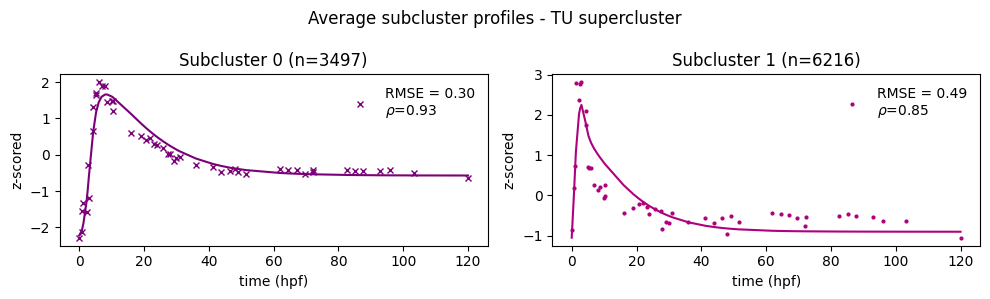

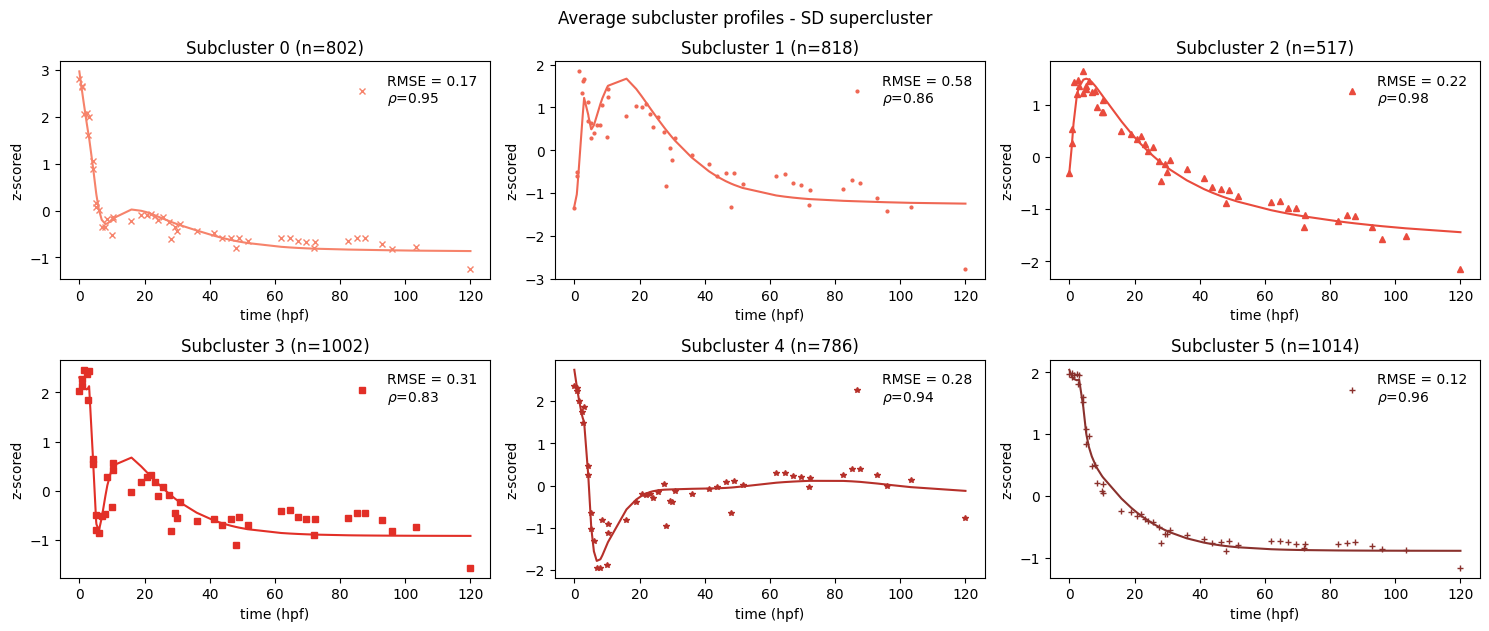

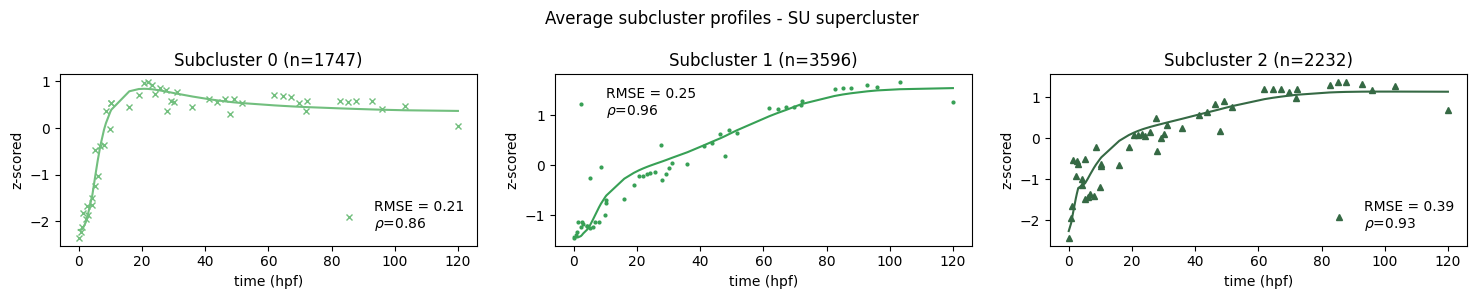

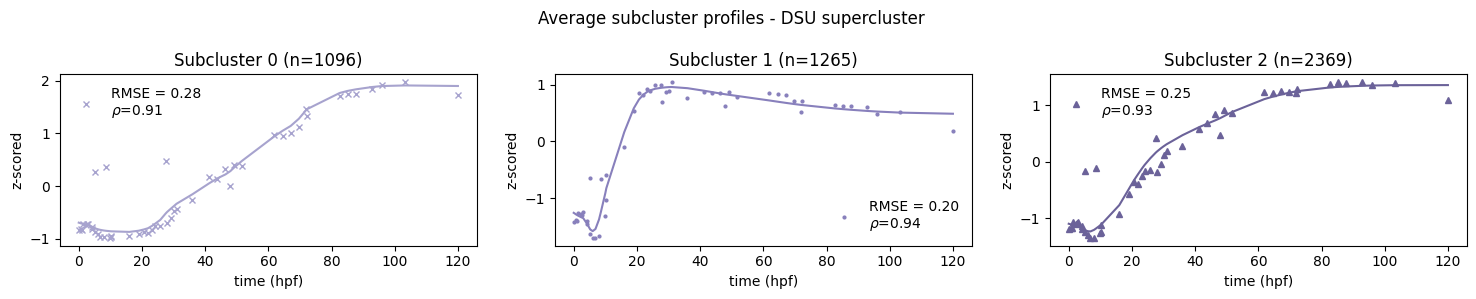

,supercluster,subcluster,RMSE,r2,spearmanr,pearsonr
0,0,0,0.296775,0.911925,0.929220,0.955962
1,0,1,0.492323,0.757618,0.847107,0.878809
2,1,0,0.167132,0.972067,0.954670,0.986033
3,1,1,0.580420,0.663113,0.860072,0.831556
4,1,2,0.221950,0.950738,0.976375,0.975369
5,1,3,0.311161,0.903179,0.830780,0.951589
6,1,4,0.283890,0.919406,0.936038,0.959703
7,1,5,0.118549,0.985946,0.963794,0.992973
8,2,0,0.205412,0.957806,0.863049,0.978903
9,2,1,0.251310,0.936843,0.960432,0.968422


In [18]:
## Subcluster Centers
labels = xr.load_dataset(f"results/joint_gene_params_cluster_annotation.nc")
ds = xr.load_dataset(f"joint_simulation_results.nc")
obs = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc").mean(dim="source").sel(ensembl_gene_id = ds.ensembl_gene_id.values)

ds["tpm"] = np.log2(ds.tpm + 1)
obs["tpm"] = np.log2(obs.tpm + 1)

#-----
gof = []
marker_map = {0:"x", 1:".", 2:"^", 3:"s", 4:"*", 5:"+", 6:"p", 7:"d", 8:">"}
n_col_max = 3

#fig, ax = plt.subplots(4,1, figsize= (8, 12), sharex=True, sharey=True)
plt.rcParams['font.family'] = 'sans-serif'
#ax=ax.flatten()
for k in range(np.unique(labels.supercluster).size):

    genes = labels.ensembl_gene_id.where(labels.supercluster == k,drop=True)
    subtraj = ds.where(ds.ensembl_gene_id.isin(genes.values), drop=True)
    sub_cluster = np.unique(genes.subcluster).size
    if sub_cluster > n_col_max:
        fig, ax = plt.subplots(int(sub_cluster/n_col_max)+1, n_col_max, figsize= (5*n_col_max, 3*int(sub_cluster/n_col_max +1)), squeeze=False)
    else:
        fig, ax = plt.subplots(1,sub_cluster, figsize= (5*sub_cluster, 3), squeeze=False)
    ax=ax.flatten()

    sc_name = p_cluster_names[k]
    
    for c in range(sub_cluster):

        gene_ids = labels['ensembl_gene_id'][(labels['supercluster'] == k) & (labels['subcluster'] == c)].values

        obs_c = obs.sel(ensembl_gene_id=gene_ids)
        obs_c_mean = zscore(obs_c.tpm.mean(dim=("ensembl_gene_id")))
        obs_c_std = zscore(obs_c.tpm.std(dim=("ensembl_gene_id",)))

        ds_c = ds.sel(ensembl_gene_id=gene_ids)
        ds_c_mean = zscore(ds_c.tpm.mean(dim=("ensembl_gene_id")))
        ds_c_std = zscore(ds_c.tpm.std(dim=("ensembl_gene_id",)))

        ax[c].plot(ds_c_mean.time, ds_c_mean, c=subcluster_color_map[sc_name][c],)
        ax[c].plot(obs_c_mean.time, obs_c_mean, ls="", marker=marker_map[c], ms=4, c=subcluster_color_map[sc_name][c], 
                   label=f"RMSE = {rmse(obs_c_mean, ds_c_mean):.2f}\n"+r"$\rho$"+f"={spearmanr(obs_c_mean, ds_c_mean)[0]:.2f}", )
        
        #ax[c].fill_between(ds_c_mean.time.values, ds_c_mean - ds_c_std,ds_c_mean + ds_c_std, alpha=0.05, color=color_map[k][c])

        gof.append({"supercluster":k, "subcluster":c, "RMSE":rmse(obs_c_mean, ds_c_mean),  "r2":r2(obs_c_mean, ds_c_mean),  
                    "spearmanr": spearmanr(obs_c_mean, ds_c_mean)[0], "pearsonr":pearsonr(obs_c_mean, ds_c_mean)[0]})
        
        ax[c].set(title=f"Subcluster {c} (n={ds_c.ensembl_gene_id.size})", ylabel= "z-scored", xlabel="time (hpf)")
        ax[c].legend(frameon=False)

    # hide unused axes beyond the number of subclusters
    for c in range(sub_cluster, len(ax)):
        ax[c].set_visible(False)

    plt.suptitle(f"Average subcluster profiles - {sc_name} supercluster")
    plt.tight_layout()
    plt.savefig(f"figs/params_subcluster_validation_{k}.png", dpi=300)
    plt.show()

pd.DataFrame(gof)

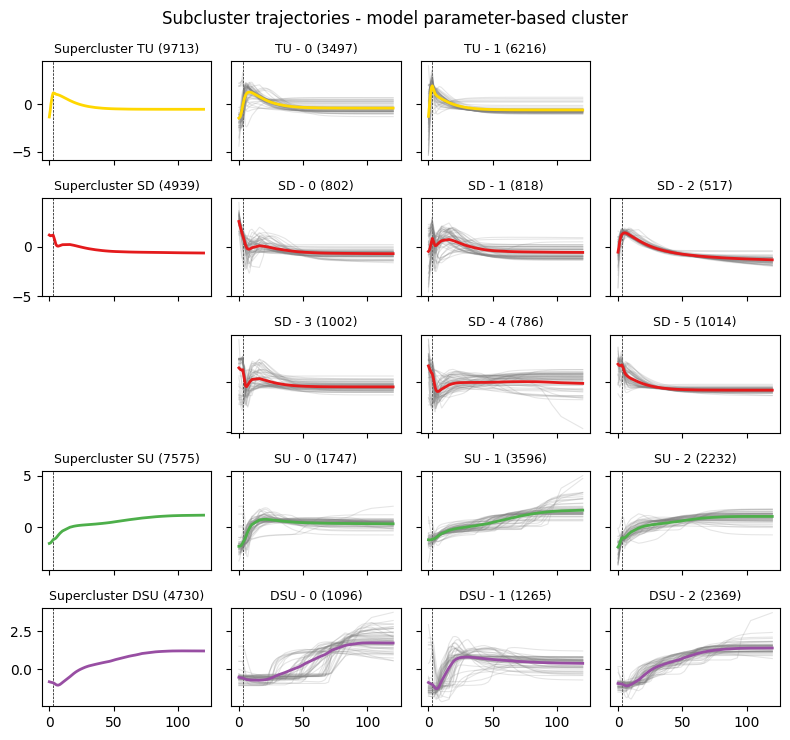

In [19]:
def plot_super_subcluster_grid(trajectories_da, super_labels, sub_labels, figsize=None):

    plt.rcParams['font.family'] = 'sans-serif'

    data = trajectories_da.values
    t = trajectories_da.time.values

    super_ids = np.unique(super_labels)
    groups = {sc: np.unique(sub_labels[(super_labels == sc) & (sub_labels >= 0)]) for sc in super_ids}

    ncols = 4         # 1 supercluster-mean column + up to 4 subcluster columns
    max_sub_per_row = ncols - 1

    # number of rows needed per supercluster (wrap subclusters in groups of 4)
    rows_per_super = {sc: max(1, int(np.ceil(len(groups[sc]) / max_sub_per_row))) for sc in super_ids}
    nrows = sum(rows_per_super.values())

    if figsize is None:
        figsize = (2 * ncols, 1.5 * nrows)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, sharex=True, sharey="row")
    axes = np.atleast_2d(axes)

    row = 0
    for sc in super_ids:
        sub_ids = groups[sc]
        sc_name = p_cluster_names[sc]
        n_rows_sc = rows_per_super[sc]

        # plot supercluster mean only on the first row for this supercluster
        idx = np.where(super_labels == sc)[0]
        subset = data[idx]
        mean_sc = subset.mean(axis=0)

        axes[row, 0].axvline(x=3, ls="--", c="k", lw=0.5)
        axes[row, 0].plot(t, mean_sc, linewidth=2, color=cluster_color_dict[sc_name])
        axes[row, 0].set_title(f"Supercluster {sc_name} ({len(subset)})", fontsize=9)

        # hide the supercluster column on any continuation rows
        for r in range(row + 1, row + n_rows_sc):
            axes[r, 0].set_visible(False)

        # place subclusters, wrapping onto new rows every max_sub_per_row
        for j, sb in enumerate(sub_ids):
            r_offset, c_offset = divmod(j, max_sub_per_row)
            ax = axes[row + r_offset, c_offset + 1]

            idx = np.where((super_labels == sc) & (sub_labels == sb))[0]
            if len(idx) == 0:
                ax.set_visible(False)
                continue

            subset = data[idx]
            mean = subset.mean(axis=0)

            ax.axvline(x=3, ls="--", c="k", lw=0.5)

            for g in range(min(50, len(subset))):
                ax.plot(t, subset[g], alpha=0.2, linewidth=0.8, color="grey")
            ax.plot(t, mean, linewidth=2, color=cluster_color_dict[sc_name])
            
            ax.set_title(f"{sc_name} - {sb} ({len(subset)})", fontsize=9)

        # hide any leftover unused subcluster slots in the last row for this supercluster
        n_used_last_row = len(sub_ids) - (n_rows_sc - 1) * max_sub_per_row
        for c in range(n_used_last_row, max_sub_per_row):
            axes[row + n_rows_sc - 1, c + 1].set_visible(False)

        row += n_rows_sc

    fig.suptitle("Subcluster trajectories - model parameter-based cluster", fontsize=12)
    plt.tight_layout()
    plt.savefig("figs/param_super_subcluster_grid.png", dpi=300)
    plt.show()

trajectories_da = xr.load_dataset("joint_simulation_results.nc").tpm
labels = xr.load_dataset(f"results/joint_gene_params_cluster_annotation.nc")
trajectories_da = trajectories_da.sel(ensembl_gene_id=labels.ensembl_gene_id)

trajectories_da = np.log2(trajectories_da+1)
trajectories_da = zscore(trajectories_da)

super_labels = labels.supercluster.values
sub_labels = labels.subcluster.values

plot_super_subcluster_grid(trajectories_da, super_labels, sub_labels, figsize=None)

### heatmap

### Sankey diagramm

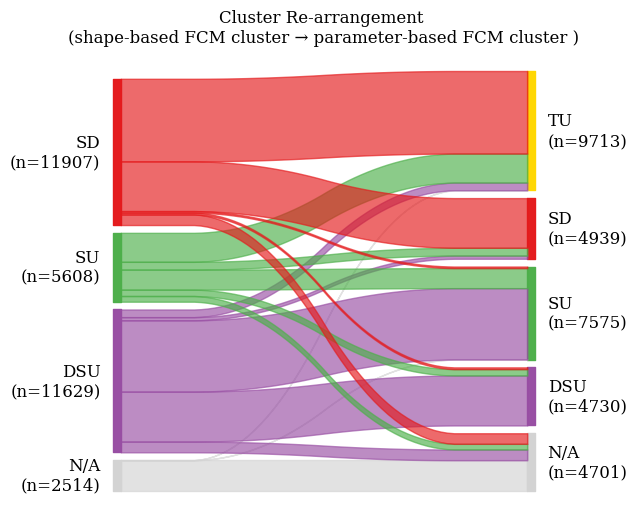

In [20]:
data = pd.read_csv("all_prefered_decay_mode.csv")
cluster = xr.load_dataset(f"results/{sc}_gene_cluster_annotation_{norm}.nc")

# Build a lookup table from the DataArray's coordinates
lookup = pd.DataFrame({
    "ensembl_gene_id": cluster["ensembl_gene_id"].values,
    "supercluster_no": cluster["supercluster"].values,
    "subcluster_no": cluster["subcluster"].values,
}).set_index("ensembl_gene_id")
lookup["supercluster"]=lookup["supercluster_no"].map(gams_cluster_names)

# Map onto df by gene_id
data["gams_cluster"] = data["ensembl_gene_id"].map(lookup["supercluster"]).fillna("N/A")
cluster = xr.load_dataset("results/joint_gene_params_cluster_annotation.nc")

plt.rcParams['font.family'] = 'sans-serif'

# Build a lookup table from the DataArray's coordinates
lookup1 = pd.DataFrame({
    "ensembl_gene_id": cluster["ensembl_gene_id"].values,
    "supercluster_no": cluster["supercluster"].values,
    "subcluster_no": cluster["subcluster"].values,
}).set_index("ensembl_gene_id")
lookup1["supercluster"]=lookup1["supercluster_no"].map(p_cluster_names)

data["ode_cluster"] = data["ensembl_gene_id"].map(lookup1["supercluster"]).fillna("N/A")

algo1 = "shape-based FCM cluster"
algo2 = "parameter-based FCM cluster "

left_counts = data["gams_cluster"].value_counts()
right_counts = data["ode_cluster"].value_counts()

def with_count(label, counts):
    n = counts.get(label, 0)
    return f"{label}\n(n={n})"

left_order_strs = [with_count(str(x), left_counts) for x in gams_cluster_order][::-1]
right_order_strs = [with_count(str(x), right_counts) for x in p_cluster_order][::-1]

# Relabel the actual data columns to match
data["gams_cluster_labeled"] = data["gams_cluster"].map(lambda x: with_count(str(x), left_counts))
data["ode_cluster_labeled"] = data["ode_cluster"].map(lambda x: with_count(str(x), right_counts))

colors_l = {with_count(str(k), left_counts): v for k, v in cluster_color_dict.items()}
colors_r = {with_count(str(k), right_counts): v for k, v in cluster_color_dict.items()}
colors = colors_l | colors_r

from pySankey.sankey import sankey
sankey(      
    left=data["gams_cluster_labeled"], 
    right=data["ode_cluster_labeled"], 
    leftLabels=list(left_order_strs),
    rightLabels=list(right_order_strs),
    aspect=20, fontsize=12,
    #figure_name=f"figs/cluster_rearrangement",
    colorDict=colors, )

# Get current figure
fig = plt.gcf()
fig.set_size_inches(6, 6)
fig.set_facecolor("w")
plt.title(f"Cluster Re-arrangement \n({algo1} → {algo2})")
fig.savefig(f"figs/cluster_agreement.png", bbox_inches="tight", dpi=300)
plt.show()

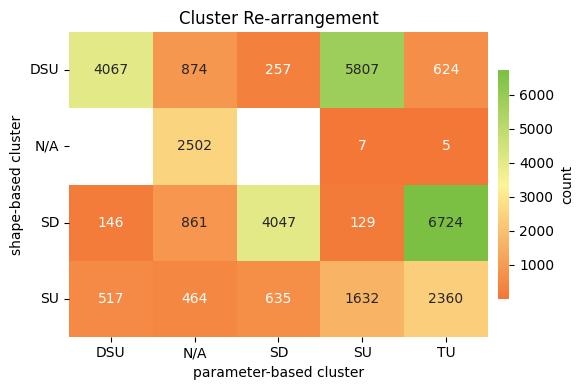

In [21]:
data = data[["ensembl_gene_id","gams_cluster", "ode_cluster"]]
matr = data.groupby(["gams_cluster", "ode_cluster"]).count().reset_index()
df_plot = matr.pivot(index="gams_cluster", columns=["ode_cluster"], values="ensembl_gene_id")

import seaborn as sns
row_totals = data.groupby("gams_cluster")["ensembl_gene_id"].count()
col_totals = data.groupby("ode_cluster")["ensembl_gene_id"].count()

cmap = sns.color_palette("blend:#f37736,#fdf498,#7bc043", as_cmap=True)

plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(6, 4),)
sns.heatmap(df_plot,annot=True, cmap=cmap, fmt=".0f", cbar_kws={'label': 'count', 'shrink': 0.75, 'pad': 0.02 })
plt.xlabel("parameter-based cluster")
plt.ylabel("shape-based cluster")
plt.yticks(rotation=0)
plt.title(f"Cluster Re-arrangement")
plt.tight_layout()
plt.savefig("figs/cluster_agreement_heatmap_Rep_jointODE.png", dpi=300)

In [ ]:
from pySankey.sankey import sankey
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def cluster_agreement(ds1, ds2, algo1, algo2):

   df1 = pd.DataFrame({"ensembl_gene_id": ds1.ensembl_gene_id.values, "cluster": ds1.values})
   df2 = pd.DataFrame({"ensembl_gene_id": ds2.ensembl_gene_id.values, "cluster2":ds2.values})

   dup1 = df1["ensembl_gene_id"].duplicated().sum()
   dup2 = df2["ensembl_gene_id"].duplicated().sum()
   if dup1 or dup2:
      print(f"Warning: {dup1} duplicate ids in ds1, {dup2} duplicate ids in ds2")

   df = df1.merge(df2, on="ensembl_gene_id", how="inner", validate="one_to_one")

   df["gams_cluster_name"] = df["cluster"].map(gams_cluster_names)
   df["params_cluster_name"] = df["cluster2"].map(p_cluster_names)

   df["agreement"] = (df["cluster"] == df["cluster2"])
   df = df.dropna(subset=["cluster", "cluster2"])
   df = df.sort_values(["cluster", "cluster2"], ascending=False)

   sankey(      
      left=df["cluster"].map(gams_cluster_names), right=df["cluster2"].map(p_cluster_names), 
      aspect=20, fontsize=12,
      figure_name=f"figs/cluster_agreement_{algo1}_{algo2}",
      colorDict=cluster_color_dict,
      )

   # Get current figure
   fig = plt.gcf()
   fig.set_size_inches(6, 6)
   fig.set_facecolor("w")
   plt.title(f"Cluster Re-arrangement \n({algo1} → {algo2})")
   fig.savefig(f"figs/cluster_agreement_{algo1}_{algo2}.png", bbox_inches="tight", dpi=300)

   agree = df["agreement"].sum() / len(df) * 100
   print(f"Cluster agreement: {agree:.2f} %")

   return df

algo1 = "shape-based FCM cluster"
ds1 = xr.load_dataset(f"results/{sc}_gene_cluster_annotation_{norm}.nc").supercluster

algo2 = "parameter-based FCM cluster "
ds2 = xr.load_dataset("results/joint_param_superclusters_labels.nc").cluster_label

df = cluster_agreement(ds1, ds2, algo1, algo2)

## Clustering

In [ ]:
# Clustering
import xarray as xr
import numpy as np
import pandas as pd
import FCM_kinetic_parameter as fc

traj120 = xr.load_dataarray(f"results/{sc}_normalized_trajectories_120_{norm}.nc")
membership120, labels120, centers120 = fc.cluster_dataset(traj120, f"results/early_superclusters", dataset_name="supercluster", k_range=range(4, 8))

# --- reindex superclusters by increasing peak time ---
peak_times = np.argmax(centers120.values, axis=1)      # peak time index per (old) cluster
new_order = np.argsort(peak_times)              # old cluster ids, sorted by peak time
rank = np.argsort(new_order)                    # rank[old_id] = new_id

# reorder centers
centers120 = centers120.isel(cluster=new_order).assign_coords(cluster=np.arange(len(new_order)))
centers120.to_netcdf(f"results/early_superclusters_centers.nc")

labels120 = labels120.copy(data=rank[labels120.values])  # remap gene labels to new ids
labels120.to_netcdf(f"results/early_superclusters_labels.nc")
fc.plot_clusters(centers120, "EarlySuperclusters")

<xarray.DataArray ()>
array(0.17558506)
Coordinates:
    ensembl_gene_id  <U18 'ENSDARG00000000001'

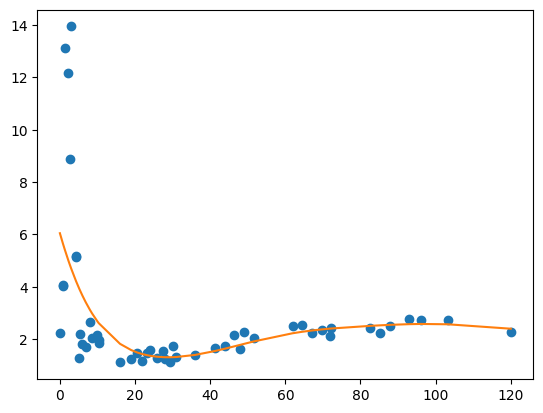

In [ ]:
ds = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(ensembl_gene_id="ENSDARG00000000001").mean(dim="source").tpm
da = xr.load_dataarray(f"results/all_gene_trajectories_120_log.nc").sel(ensembl_gene_id="ENSDARG00000000001")
da = np.exp2(da) -1

plt.plot(ds.time, ds, "o")
plt.plot(da.time, da,)

rmse = np.sqrt(np.mean((ds - da)**2))
n_range = np.max(ds) - np.min(ds)
nrmse = rmse / n_range if n_range > 0 else np.nan
nrmse

In [ ]:
trajectories = xr.load_dataarray(f"results/all_gene_trajectories_120_log.nc")
trajectories

trajectories = np.exp2(trajectories) -1
trajectories

<xarray.DataArray 'trajectory' (ensembl_gene_id: 31658, time: 50)>
array([[6.04379174e+00, 5.67568019e+00, 5.61641329e+00, ...,
        2.57607027e+00, 2.56364693e+00, 2.39414589e+00],
       [1.05909541e+00, 9.63178308e-01, 9.47893463e-01, ...,
        1.27438393e+01, 1.21650219e+01, 8.24275822e+00],
       [4.24925746e+01, 4.21649168e+01, 4.21105473e+01, ...,
        1.56259110e+01, 1.44749633e+01, 1.20905196e+01],
       ...,
       [2.23578816e+00, 2.27039660e+00, 2.27630513e+00, ...,
        1.10472104e+01, 1.06106273e+01, 8.57587644e+00],
       [1.26663839e-01, 1.24694187e-01, 1.24366478e-01, ...,
        2.09051384e-02, 2.36245507e-02, 3.04698415e-02],
       [3.37374023e-03, 3.30099360e-03, 3.28888825e-03, ...,
        2.50350386e-02, 2.92042335e-02, 3.88093811e-02]])
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENSDA...
  * time             (time) float64 0.0 0.75 0.875 1.29 ... 96.0 103.2 120.0

<xarray.DataArray ()>
array(0.161398)
Coordinates:
    ensembl_gene_id  <U18 'ENSDARG00000000001'

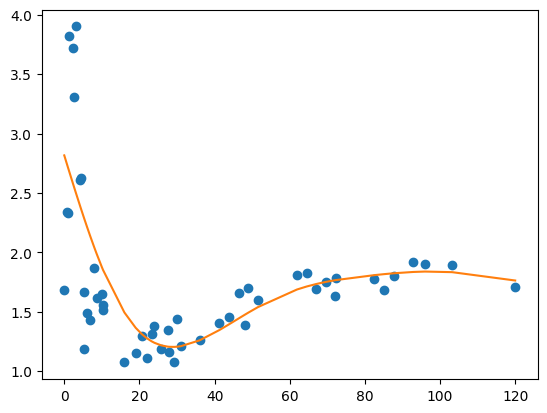

In [ ]:
ds = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(ensembl_gene_id="ENSDARG00000000001").mean(dim="source").tpm
ds = np.log2(ds + 1)
da = xr.load_dataarray(f"results/all_gene_trajectories_120_log.nc").sel(ensembl_gene_id="ENSDARG00000000001")

plt.plot(ds.time, ds, "o")
plt.plot(da.time, da,)

rmse = np.sqrt(np.mean((ds - da)**2))
n_range = np.max(ds) - np.min(ds)
nrmse = rmse / n_range if n_range > 0 else np.nan
nrmse

Kept 23428 / 23428 genes after dynamic range filter (>= 1.0 log2 units)


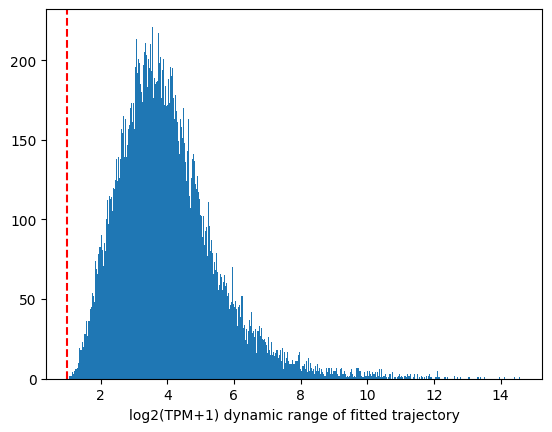

In [ ]:
ds = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc")
ds_clean = ds.dropna(dim="time", how="all", subset=["tpm"])
mask = ((ds_clean.tpm.max(dim="time", skipna=True) >= 1) & (ds_clean.tpm.std(("time")) > 0.05)).all(dim="source")
ds_clean = ds_clean.sel(ensembl_gene_id=mask)
ds_clean["tpm"] = np.log2(ds_clean.tpm + 1)

# Compute dynamic range of fitted trajectory in log2(TPM+1) space, before min-max scaling
dyn_range = ds_clean.tpm.max(dim=("time", "source")) - ds_clean.tpm.min(dim=("time", "source"))

MIN_LOG2_RANGE = 1.0  # e.g. >= 2-fold change; tune based on inspection below
range_mask = dyn_range >= MIN_LOG2_RANGE
trajectories_filtered = ds_clean.sel(ensembl_gene_id=range_mask)

print(f"Kept {range_mask.sum().item()} / {ds_clean.sizes['ensembl_gene_id']} genes "
      f"after dynamic range filter (>= {MIN_LOG2_RANGE} log2 units)")

import matplotlib.pyplot as plt
dyn_range.plot.hist(bins=500)
plt.axvline(MIN_LOG2_RANGE, color="red", linestyle="--")
plt.xlabel("log2(TPM+1) dynamic range of fitted trajectory")
plt.show()

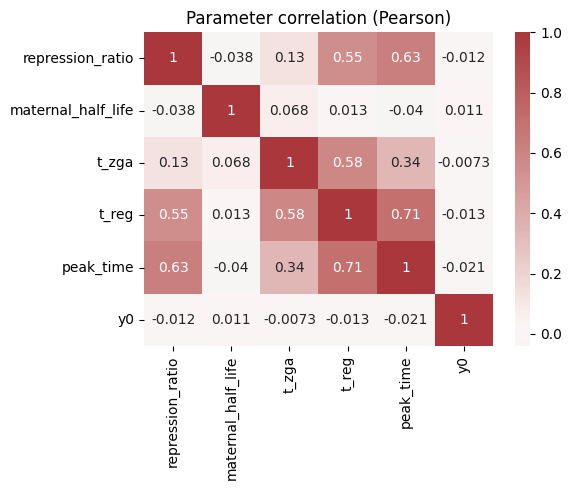

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
params = ["repression_ratio", "maternal_half_life", "t_zga", "t_reg", "peak_time", "y0"]

plt.rcParams['font.family'] = 'sans-serif'

ds = xr.load_dataset(f"joint_params_results.nc")
df = ds[params].to_dataframe().drop(columns=["time", "model"])
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(method="pearson"),    annot=True,    cmap="vlag",    center=0,)
plt.title(f"Parameter correlation (Pearson)")
plt.tight_layout()
plt.show()